<a href="https://colab.research.google.com/github/siddihboi49/CS3807-Deep-Learning-Lab/blob/main/Experiment1_Single_Layer_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# ============================================================
# Experiment 1: Single Layer Perceptron
# Deep Learning Laboratory
#
# Environment Setup
# ============================================================

!pip install -q pandas numpy matplotlib seaborn scikit-learn

In [11]:
# ============================================================
# Import Libraries
# ============================================================

import os
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


print("Libraries imported successfully")

Libraries imported successfully


In [38]:
# ============================================================
# Experiment Configuration
# ============================================================


CONFIG = {

    "dataset_path":
    "data_banknote_authentication.txt",

    "random_seed":
    42,

    "test_size":
    0.20,

    "plot_size":
    (8,6),

    "dpi":
    300,

    # Perceptron hyperparameters

    "learning_rate": 0.01,

    "epochs": 100


}


CONFIG

{'dataset_path': 'data_banknote_authentication.txt',
 'random_seed': 42,
 'test_size': 0.2,
 'plot_size': (8, 6),
 'dpi': 300,
 'learning_rate': 0.01,
 'epochs': 100}

In [39]:
# ============================================================
# Reproducibility
# ============================================================


def set_seed(seed):

    """
    Fixes random seeds to ensure
    repeatable experiments.
    """

    random.seed(seed)

    np.random.seed(seed)


set_seed(CONFIG["random_seed"])

print("Random seed fixed")

Random seed fixed


In [40]:
from google.colab import files

uploaded = files.upload()


Saving data_banknote_authentication.txt to data_banknote_authentication (1).txt


In [41]:
# ============================================================
# Dataset Loading
# ============================================================


COLUMN_NAMES = [

    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class"

]


def load_dataset(path):

    """
    Loads Banknote Authentication Dataset.

    Parameters:
    -----------
    path : str
        Dataset location

    Returns:
    --------
    DataFrame
        Loaded dataset
    """


    dataframe = pd.read_csv(

        path,

        header=None,

        names=COLUMN_NAMES

    )


    return dataframe



df = load_dataset(
    CONFIG["dataset_path"]
)


df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [44]:
# ============================================================
# Dataset Understanding
# ============================================================


print("Dataset Shape:")
print(df.shape)


print("\nDataset Information:")
df.info()


print("\nMissing Values:")
print(df.isnull().sum())


print("\nStatistical Summary:")
df.describe()

Dataset Shape:
(1372, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB

Missing Values:
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

Statistical Summary:


,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


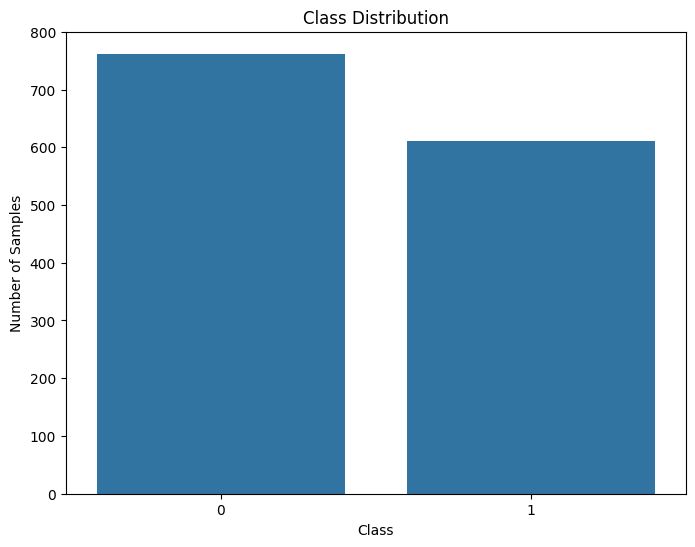

In [45]:
plt.figure(figsize=CONFIG["plot_size"])


sns.countplot(

    data=df,

    x="class"

)


plt.title(
    "Class Distribution"
)

plt.xlabel(
    "Class"
)

plt.ylabel(
    "Number of Samples"
)


plt.show()

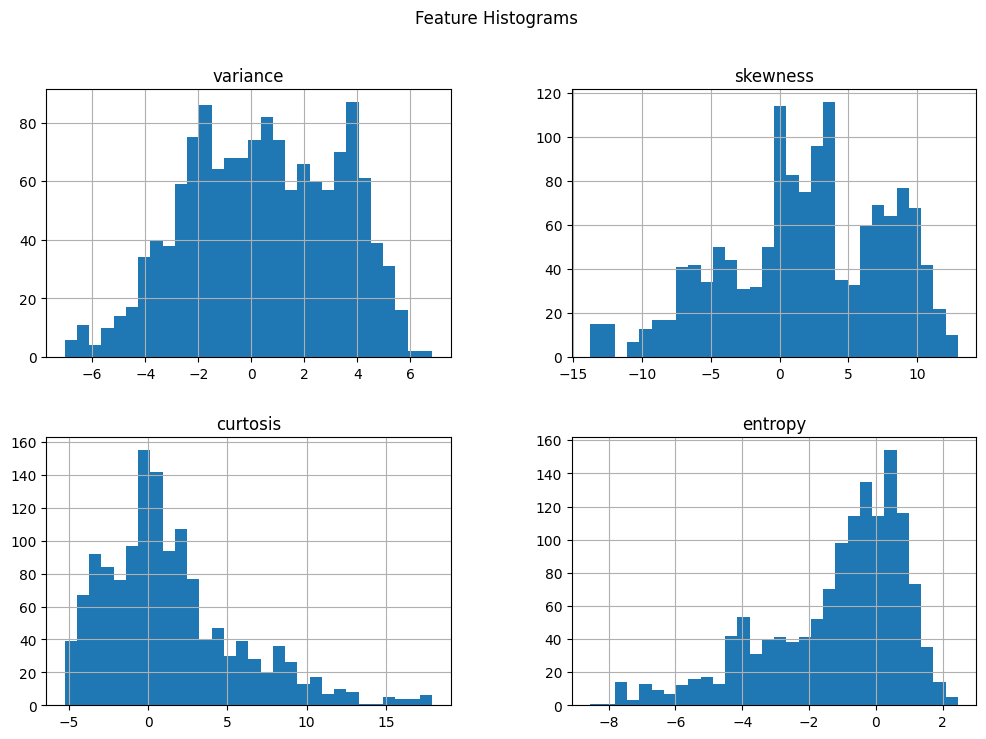

In [46]:
# ============================================================
# Feature Distribution
# ============================================================


df.drop(
    "class",
    axis=1
).hist(

    figsize=(12,8),

    bins=30

)


plt.suptitle(
    "Feature Histograms"
)


plt.show()

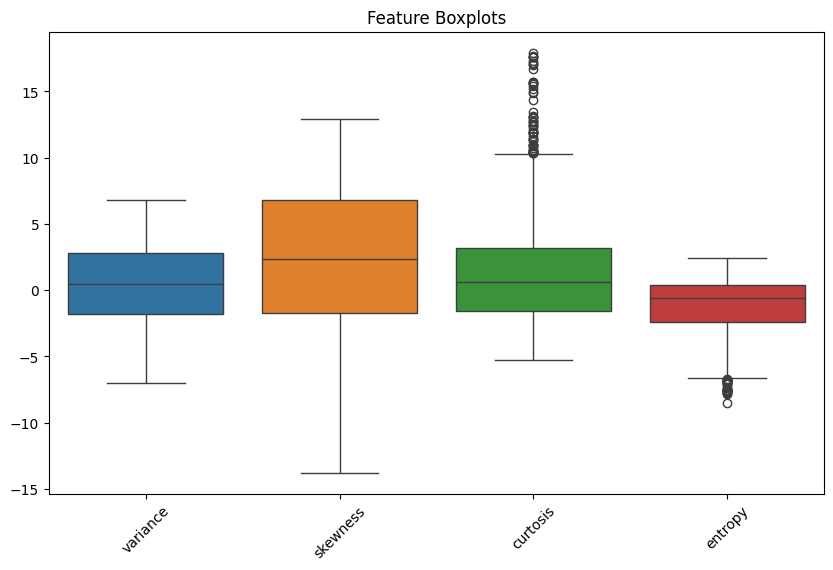

In [47]:
plt.figure(figsize=(10,6))


sns.boxplot(

    data=df.drop(
        "class",
        axis=1
    )

)


plt.title(
    "Feature Boxplots"
)


plt.xticks(rotation=45)


plt.show()

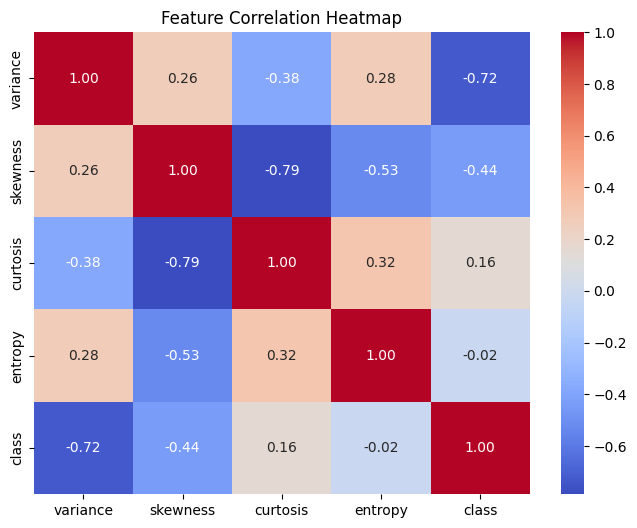

In [48]:
plt.figure(figsize=(8,6))


sns.heatmap(

    df.corr(),

    annot=True,

    cmap="coolwarm",

    fmt=".2f"

)


plt.title(
    "Feature Correlation Heatmap"
)


plt.show()

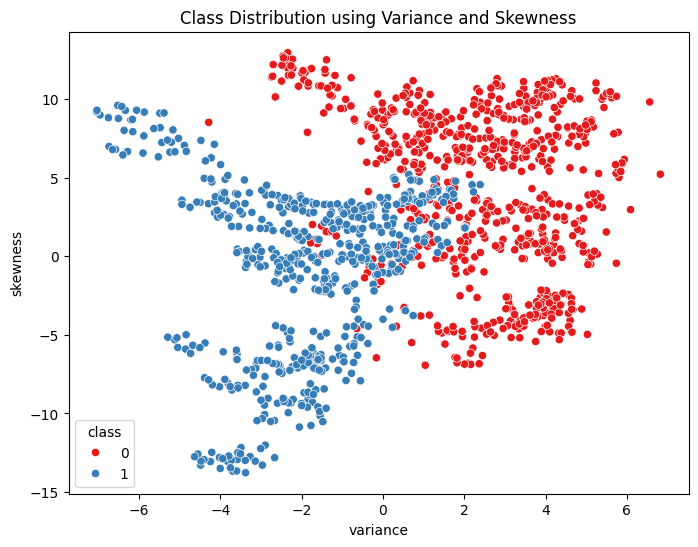

In [49]:
plt.figure(figsize=(8,6))


sns.scatterplot(

    data=df,

    x="variance",

    y="skewness",

    hue="class",

    palette="Set1"

)


plt.title(
    "Class Distribution using Variance and Skewness"
)


plt.show()

In [50]:
# ============================================================
# Save Generated Outputs
# ============================================================


OUTPUT_DIR = Path("outputs")

OUTPUT_DIR.mkdir(
    exist_ok=True
)


df.describe().to_csv(
    OUTPUT_DIR / "dataset_statistics.csv"
)


print(
    "Results saved successfully"
)

Results saved successfully


In [51]:
#Feature Separation
X = df.drop(
    "class",
    axis=1
)


y = df["class"]

In [52]:
#Train and Test split
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=CONFIG["test_size"],

    random_state=CONFIG["random_seed"],

    stratify=y

)

In [53]:
#Normalization
scaler = StandardScaler()


X_train = scaler.fit_transform(
    X_train
)


X_test = scaler.transform(
    X_test
)

In [54]:
#Verification
print(X_train.shape)
print(X_test.shape)

(1097, 4)
(275, 4)


In [55]:
#============================================================
# Additional Imports for Perceptron Implementation
#============================================================

import matplotlib.pyplot as plt

In [56]:
# ============================================================
# Single Layer Perceptron Implementation
# ============================================================


class SingleLayerPerceptron:

    """
    Implementation of a binary classifier
    using the Perceptron learning algorithm.
    """


    def __init__(
        self,
        learning_rate=0.01,
        epochs=100
    ):

        """
        Initialize perceptron parameters.

        Parameters
        ----------
        learning_rate : float
            Controls weight update magnitude.

        epochs : int
            Number of training iterations.
        """


        self.learning_rate = learning_rate

        self.epochs = epochs

        self.weights = None

        self.bias = None

        self.errors = []

        self.weight_history = []

        self.bias_history = []



    def step_function(
        self,
        z
    ):

        """
        Binary step activation function.
        """


        return np.where(
            z >= 0,
            1,
            0
        )



    def predict(
        self,
        X
    ):

        """
        Generate predictions.

        Formula:

        z = Xw + b

        """

        z = np.dot(

            X,

            self.weights

        ) + self.bias


        return self.step_function(z)



    def fit(
        self,
        X,
        y
    ):

        """
        Train perceptron using
        perceptron learning rule.
        """


        number_of_features = X.shape[1]


        # Initialize parameters

        self.weights = np.zeros(
            number_of_features
        )


        self.bias = 0



        # Training loop

        for epoch in range(self.epochs):


            misclassified = 0



            for xi, target in zip(X, y):


                prediction = self.predict(
                    xi
                )


                update = (

                    self.learning_rate

                    *

                    (target - prediction)

                )



                if update != 0:


                    misclassified += 1



                # Update weights

                self.weights += (

                    update * xi

                )


                # Update bias

                self.bias += update



            # Store epoch information

            self.errors.append(
                misclassified
            )


            self.weight_history.append(
                self.weights.copy()
            )


            self.bias_history.append(
                self.bias
            )



            print(

                f"Epoch {epoch+1}/{self.epochs} "
                f"- Errors: {misclassified}"

            )


        return self


# ============================================================
# Model Training
# ============================================================


perceptron = SingleLayerPerceptron(

    learning_rate=CONFIG["learning_rate"],

    epochs=CONFIG["epochs"]

)



perceptron.fit(

    X_train,

    y_train.values

)

Epoch 1/100 - Errors: 51
Epoch 2/100 - Errors: 32
Epoch 3/100 - Errors: 27
Epoch 4/100 - Errors: 25
Epoch 5/100 - Errors: 27
Epoch 6/100 - Errors: 20
Epoch 7/100 - Errors: 20
Epoch 8/100 - Errors: 23
Epoch 9/100 - Errors: 21
Epoch 10/100 - Errors: 22
Epoch 11/100 - Errors: 18
Epoch 12/100 - Errors: 20
Epoch 13/100 - Errors: 22
Epoch 14/100 - Errors: 26
Epoch 15/100 - Errors: 19
Epoch 16/100 - Errors: 18
Epoch 17/100 - Errors: 24
Epoch 18/100 - Errors: 17
Epoch 19/100 - Errors: 17
Epoch 20/100 - Errors: 15
Epoch 21/100 - Errors: 12
Epoch 22/100 - Errors: 14
Epoch 23/100 - Errors: 18
Epoch 24/100 - Errors: 16
Epoch 25/100 - Errors: 12
Epoch 26/100 - Errors: 19
Epoch 27/100 - Errors: 19
Epoch 28/100 - Errors: 20
Epoch 29/100 - Errors: 19
Epoch 30/100 - Errors: 18
Epoch 31/100 - Errors: 14
Epoch 32/100 - Errors: 18
Epoch 33/100 - Errors: 18
Epoch 34/100 - Errors: 17
Epoch 35/100 - Errors: 17
Epoch 36/100 - Errors: 18
Epoch 37/100 - Errors: 16
Epoch 38/100 - Errors: 12
Epoch 39/100 - Errors

In [57]:
perceptron = SingleLayerPerceptron(

    learning_rate=CONFIG["learning_rate"],

    epochs=CONFIG["epochs"]

)


perceptron.fit(

    X_train,

    y_train.values

)

Epoch 1/100 - Errors: 51
Epoch 2/100 - Errors: 32
Epoch 3/100 - Errors: 27
Epoch 4/100 - Errors: 25
Epoch 5/100 - Errors: 27
Epoch 6/100 - Errors: 20
Epoch 7/100 - Errors: 20
Epoch 8/100 - Errors: 23
Epoch 9/100 - Errors: 21
Epoch 10/100 - Errors: 22
Epoch 11/100 - Errors: 18
Epoch 12/100 - Errors: 20
Epoch 13/100 - Errors: 22
Epoch 14/100 - Errors: 26
Epoch 15/100 - Errors: 19
Epoch 16/100 - Errors: 18
Epoch 17/100 - Errors: 24
Epoch 18/100 - Errors: 17
Epoch 19/100 - Errors: 17
Epoch 20/100 - Errors: 15
Epoch 21/100 - Errors: 12
Epoch 22/100 - Errors: 14
Epoch 23/100 - Errors: 18
Epoch 24/100 - Errors: 16
Epoch 25/100 - Errors: 12
Epoch 26/100 - Errors: 19
Epoch 27/100 - Errors: 19
Epoch 28/100 - Errors: 20
Epoch 29/100 - Errors: 19
Epoch 30/100 - Errors: 18
Epoch 31/100 - Errors: 14
Epoch 32/100 - Errors: 18
Epoch 33/100 - Errors: 18
Epoch 34/100 - Errors: 17
Epoch 35/100 - Errors: 17
Epoch 36/100 - Errors: 18
Epoch 37/100 - Errors: 16
Epoch 38/100 - Errors: 12
Epoch 39/100 - Errors

In [58]:
print("Final Weights:")
print(perceptron.weights)


print("\nFinal Bias:")
print(perceptron.bias)

Final Weights:
[-0.22298399 -0.26903532 -0.24649669 -0.00438611]

Final Bias:
-0.10999999999999999


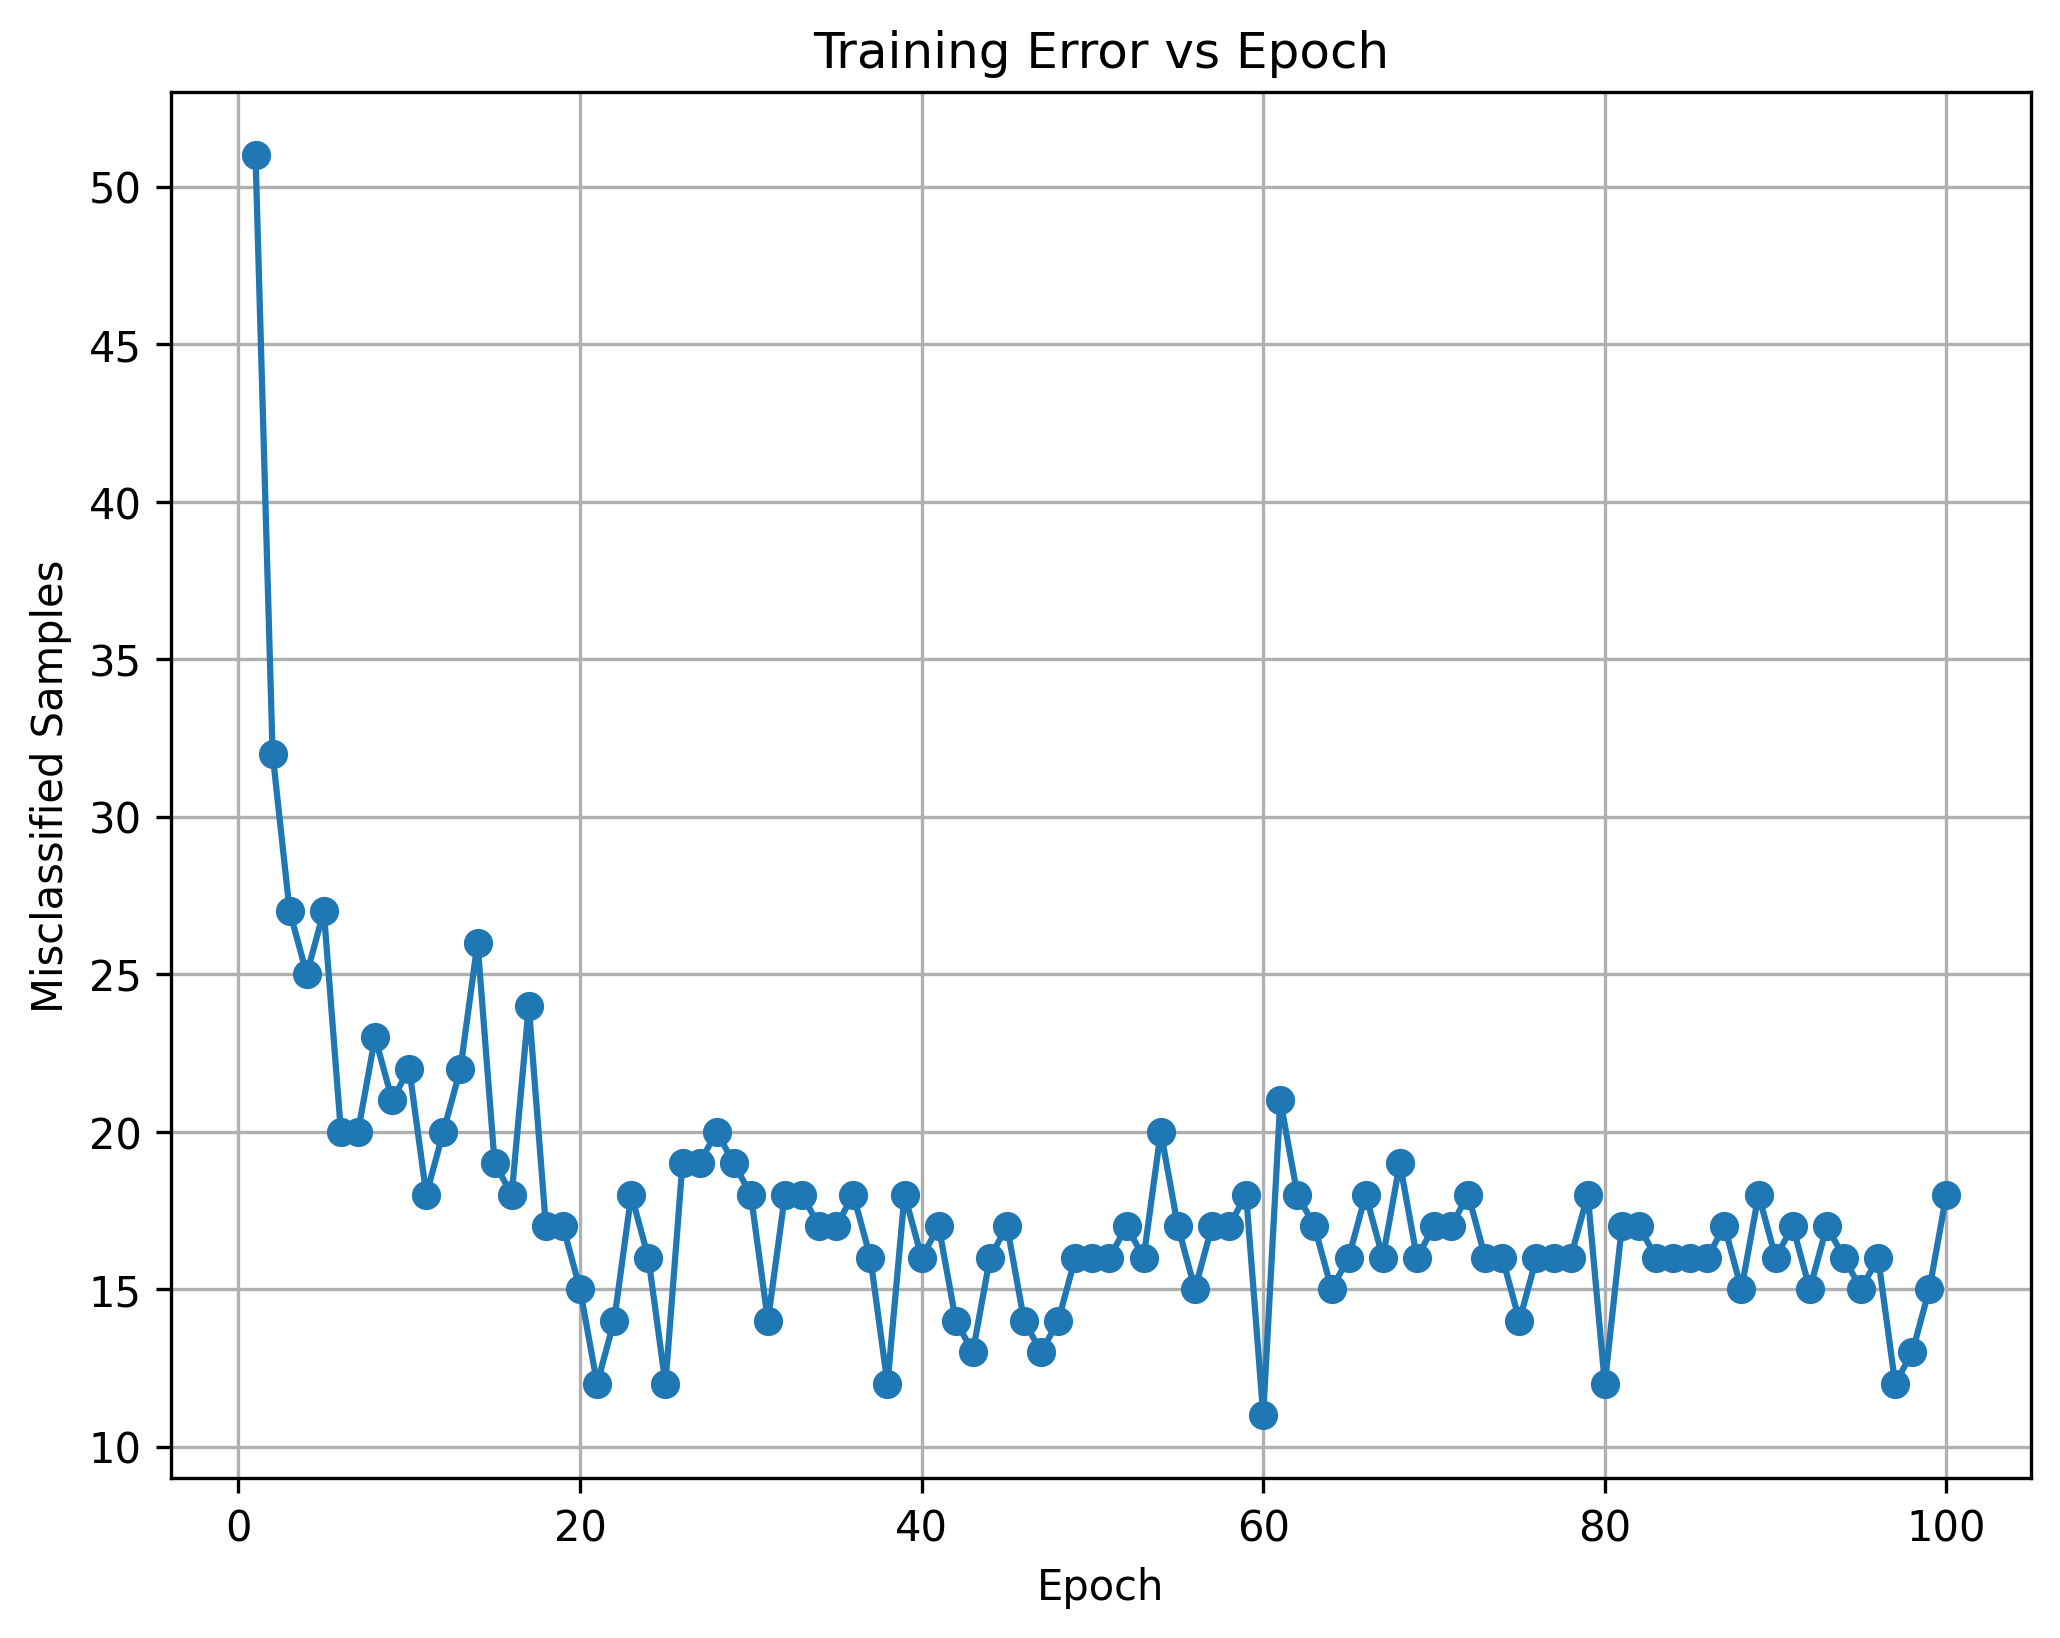

In [59]:
plt.figure(
    figsize=CONFIG["plot_size"],
    dpi=CONFIG["dpi"]
)


plt.plot(

    range(1, CONFIG["epochs"] + 1),

    perceptron.errors,

    marker="o"

)


plt.xlabel("Epoch")

plt.ylabel("Misclassified Samples")

plt.title(
    "Training Error vs Epoch"
)


plt.grid(True)

plt.show()

In [60]:
predictions = perceptron.predict(
    X_test
)


predictions[:10]

array([0, 1, 0, 1, 1, 1, 0, 0, 0, 1])

In [61]:
np.unique(
    predictions,
    return_counts=True
)

(array([0, 1]), array([149, 126]))

In [62]:
training_history = pd.DataFrame({

    "Epoch":
    range(1, CONFIG["epochs"] + 1),

    "Errors":
    perceptron.errors

})


training_history.head()

,Epoch,Errors
0,1,51
1,2,32
2,3,27
3,4,25
4,5,27


In [63]:
training_history.to_csv(
    "perceptron_training_history.csv",
    index=False
)